# Notebook 8

This is a first try to explore how ABP behaves for the narrow escape problem

In [1]:
import numpy as np
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
from stage_escape.surface import Surface
from stage_escape.escape import Escape
from stage_escape.abp_abf.abp_equivalent_narrow_escape import ABPEquivalentNarrowEscape
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.statistics import Statistics
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

In [2]:
NUM_STEPS = 10000
DELTA_T = 0.0001
DIMENSION = 2
SEED = 42  # Set a seed for reproducibility

[ 0.01195728 -0.01130647]
[ 0.00068914 -0.03171946]
[ 0.00372812 -0.02167131]
[-0.02518231 -0.02574748]
[-0.03315382 -0.0228784 ]
[-0.05190432 -0.0387854 ]
[-0.05100403 -0.04415721]
[-0.06268868 -0.0546724 ]
[-0.06831379 -0.0565014 ]
[-0.07140423 -0.0680014 ]
[-0.07296805 -0.05478564]
[-0.0820761  -0.05427965]
[-0.09205026 -0.04320896]
[-0.09505538 -0.05112201]
[-0.09326419 -0.06725742]
[-0.09908788 -0.07329279]
[-0.0883602  -0.06716184]
[-0.07756638 -0.07255317]
[-0.07671721 -0.07191973]
[-0.07887073 -0.06365635]
[-0.08458763 -0.07529355]
[-0.10883409 -0.06559454]
[-0.09590612 -0.08464687]
[-0.11116375 -0.09545226]
[-0.12068925 -0.09636975]
[-0.12333256 -0.10297836]
[-0.10730708 -0.10829983]
[-0.11295925 -0.10910461]
[-0.11208746 -0.09899198]
[-0.13493697 -0.08578226]
[-0.14327593 -0.09994098]
[-0.13669635 -0.09693019]
[-0.13718016 -0.0916493 ]
[-0.13698937 -0.09487832]
[-0.13218818 -0.09569069]
[-0.12677385 -0.0874897 ]
[-0.12923885 -0.07822413]
[-0.12662909 -0.08310596]
[-0.13094672

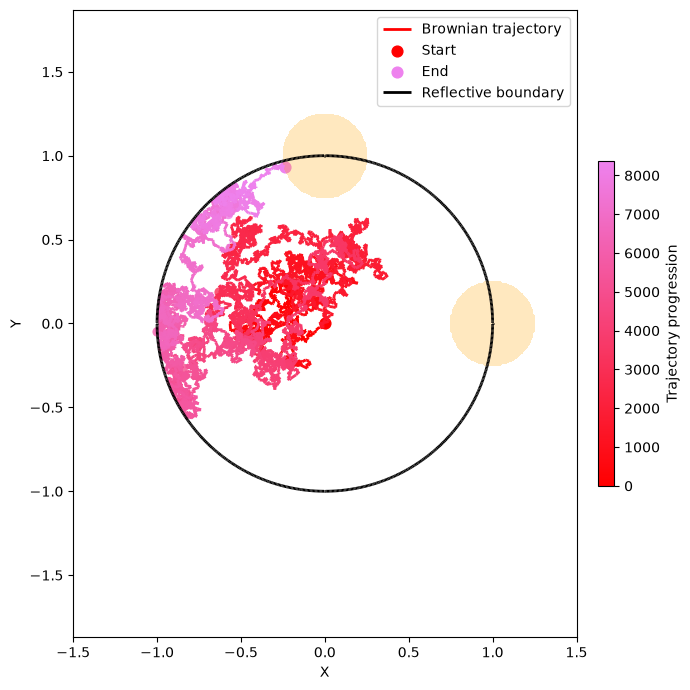

In [ ]:

# Surface defined by the equation x^2 + y^2 = 1 (unit circle)
surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

point1 = np.array([1, 0])
escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 2) <= (0.5 / 2) ** 2]) # Escape region

point2 = np.array([0, 1])
escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 2) <= (0.5 / 2) ** 2])

def cv(x):
    if escape1.conditions[0](x) or escape2.conditions[0](x):
        return 1
    return -1

td = TransitionDetector(np.array([]), cv=cv, threshold=0)

abp = ABPMetaDynamics(num_steps=10, td=td, delta_t=DELTA_T, dimension=DIMENSION)

narrow_escape = ABPEquivalentNarrowEscape(abp, surface, [escape1, escape2])

escape_point, escape_time = narrow_escape.run_simulation()
print(f'Escape time: {escape_time}')
narrow_escape.plot_narrow_escape_problem()


In [ ]:
def run_one_simulation_2d(epsilon1, epsilon2):
    ABPEquivalentNarrowEscape = BrownianMotion(num_steps=NUM_STEPS, delta_t=DELTA_T, dimension=DIMENSION)

    # Surface defined by the equation x^2 + y^2 = 1 (unit circle)
    surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

    point1 = np.array([1, 0])
    escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 2) <= (epsilon1 / 2) ** 2]) # Escape region

    point2 = np.array([-1, 0])
    escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 2) <= (epsilon2 / 2) ** 2])

    narrow_escape = EquivalentNarrowEscape(bm, surface, [escape1, escape2])

    escape_point, escape_time = narrow_escape.run_simulation()
    return escape_point, escape_time